# Google Colab Lab Assignment - Generative AI Lab

## Practical No-03: Autoencoder and Variational Autoencoder for Image Reconstruction

**Course Name:** Generative AI Lab

**Lab Title:** Autoencoder and Variational Autoencoder for Image Reconstruction

**Student Name:** Shreya Dattaram Bhosale

**PRN Number:** 202502110010

**Batch:** A3

**Github Link:** https://github.com/bhosaleshreya25/Generative-AI/tree/main/Practical_03


# 1. Aim

Build an **Autoencoder** and a **Variational Autoencoder (VAE)** for image reconstruction and generation. Compare the performance of both models by analyzing the quality of reconstructed and generated images.


# 2. Objectives

1. Understand the architecture and working of an Autoencoder.
2. Implement a Convolutional Autoencoder for image reconstruction.
3. Understand the probabilistic latent space used by a Variational Autoencoder.
4. Implement a Convolutional VAE using the reparameterization trick.
5. Reconstruct EMNIST handwritten-letter images using both models.
6. Generate new images from random latent vectors using the VAE.
7. Compare the models using reconstruction loss, visual quality, and latent-space behavior.
8. Analyze the strengths, limitations, and possible improvements of both approaches.


# 3. Theory

## 3.1 Autoencoder

An **Autoencoder (AE)** is a neural network that learns to reproduce its input at the output. It contains:

- **Encoder:** compresses the input image into a lower-dimensional latent representation.
- **Latent space:** stores the compact representation learned by the encoder.
- **Decoder:** reconstructs the image from the latent representation.

The model is trained by minimizing the difference between the original image and reconstructed image.

For this practical, **Mean Squared Error (MSE)** is used as the reconstruction loss.

### Basic flow

**Input Image → Encoder → Latent Vector → Decoder → Reconstructed Image**

## 3.2 Variational Autoencoder

A **Variational Autoencoder (VAE)** is a generative version of an Autoencoder. Instead of learning one fixed latent vector, the encoder learns a probability distribution represented by:

- **μ (mean)**
- **log σ² (log variance)**

A latent vector is sampled using the reparameterization trick:

**z = μ + σ × ε**

where ε is sampled from a standard normal distribution.

The VAE uses two main loss components:

1. **Reconstruction Loss:** makes the generated/reconstructed image similar to the input.
2. **KL Divergence:** regularizes the latent distribution toward a standard normal distribution.

Therefore:

**VAE Loss = Reconstruction Loss + β × KL Divergence**

A VAE is particularly useful for generation because its latent space is regularized and can be sampled.


# 4. Dataset Selection: EMNIST Letters

The **EMNIST Letters** dataset is selected for this practical because it provides more variety than a very basic handwritten-digit dataset while keeping the image size small enough for practical experimentation.

### Dataset characteristics

- **Classes:** 26 handwritten English letters
- **Image size:** 28 × 28 pixels
- **Image type:** Grayscale
- **Channels:** 1
- **Training subset used:** 30,000 images
- **Test subset used:** 5,000 images

Only a subset is used for training so that the practical remains manageable in Google Colab.

> **Important:** `torchvision` downloads the EMNIST archive containing the full dataset even though this notebook trains on a subset. The subset controls training time and memory use, not the archive download size.


# 5. Task 1: Environment Setup and Reproducibility

The implementation uses PyTorch and torchvision. A fixed random seed is used where possible so that the experiment is easier to reproduce.


In [25]:
# Install / import required libraries

import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)


PyTorch version: 2.11.0+cu128
Device: cuda


# 6. Experimental Configuration

The following configuration keeps the experiment at a practical level while providing enough capacity for meaningful reconstruction and generation.


In [26]:
BATCH_SIZE = 128
LATENT_DIM = 32
EPOCHS = 20
LEARNING_RATE = 0.001
BETA = 0.0005

TRAIN_SIZE = 30000
TEST_SIZE = 5000

print("Training subset :", TRAIN_SIZE)
print("Testing subset  :", TEST_SIZE)
print("Batch size      :", BATCH_SIZE)
print("Latent dimension:", LATENT_DIM)
print("Epochs          :", EPOCHS)
print("Learning rate   :", LEARNING_RATE)
print("VAE beta        :", BETA)


Training subset : 30000
Testing subset  : 5000
Batch size      : 128
Latent dimension: 32
Epochs          : 20
Learning rate   : 0.001
VAE beta        : 0.0005


# 7. Task 1.1: Dataset Download and Preprocessing

The images are converted to tensors using `ToTensor()`. Pixel values are scaled to the range **[0, 1]**, which matches the Sigmoid activation used at the decoder output.


In [27]:
transform = transforms.ToTensor()

train_full = datasets.EMNIST(
    root="./data",
    split="letters",
    train=True,
    download=True,
    transform=transform
)

test_full = datasets.EMNIST(
    root="./data",
    split="letters",
    train=False,
    download=True,
    transform=transform
)

train_ds = Subset(train_full, range(TRAIN_SIZE))
test_ds = Subset(test_full, range(TEST_SIZE))

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Full training dataset:", len(train_full))
print("Full test dataset:", len(test_full))
print("Training subset:", len(train_ds))
print("Test subset:", len(test_ds))


Full training dataset: 124800
Full test dataset: 20800
Training subset: 30000
Test subset: 5000


# 7.1 Dataset Inspection

The following cell checks the image shape and pixel-value range before model training.


In [28]:
images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Single image shape:", images[0].shape)
print("Minimum pixel value:", images.min().item())
print("Maximum pixel value:", images.max().item())
print("Label range in batch:", labels.min().item(), "to", labels.max().item())


Batch image shape: torch.Size([128, 1, 28, 28])
Single image shape: torch.Size([1, 28, 28])
Minimum pixel value: 0.0
Maximum pixel value: 1.0
Label range in batch: 1 to 26


# 7.2 Sample Image Visualization

Sample EMNIST letter images are displayed to verify that the dataset has been loaded correctly.


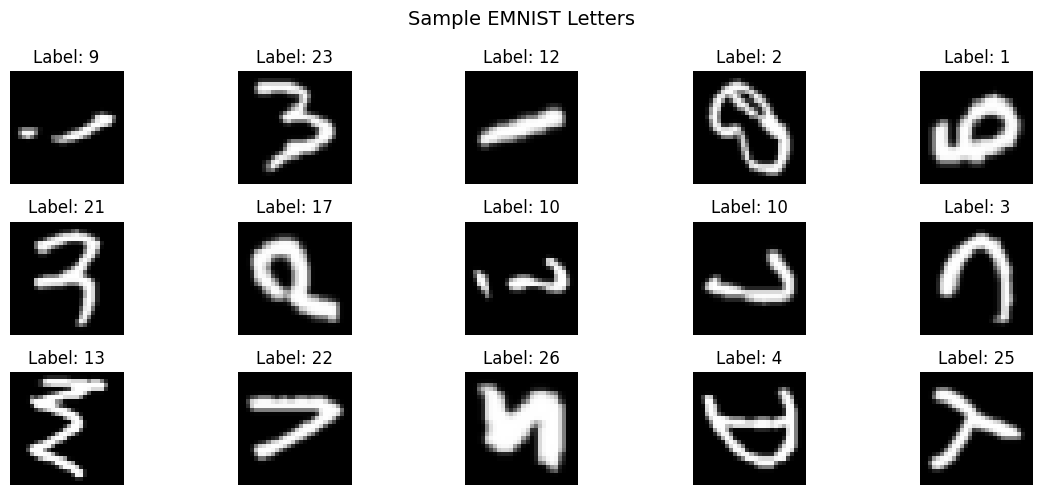

In [29]:
plt.figure(figsize=(12, 5))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap="gray")
    plt.title(f"Label: {labels[i].item()}")
    plt.axis("off")

plt.suptitle("Sample EMNIST Letters", fontsize=14)
plt.tight_layout()
plt.show()


# 8. Task 2: Convolutional Autoencoder

The Autoencoder uses convolutional layers to learn spatial features from the handwritten letters.

### Architecture

**Encoder**
- Conv2D: 1 → 32 channels
- Conv2D: 32 → 64 channels
- Flatten
- Fully connected latent representation of 32 dimensions

**Decoder**
- Fully connected layer
- ConvTranspose2D: 64 → 32 channels
- ConvTranspose2D: 32 → 1 channel
- Sigmoid output

In [30]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64 * 7 * 7),
            nn.ReLU(),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(
                64, 32, 3, stride=2,
                padding=1, output_padding=1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                32, 1, 3, stride=2,
                padding=1, output_padding=1
            ),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        output = self.decoder(z)
        return output

ae = Autoencoder(LATENT_DIM).to(device)

print(ae)


Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=3136, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=3136, bias=True)
    (1): ReLU()
    (2): Unflatten(dim=1, unflattened_size=(64, 7, 7))
    (3): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): ReLU()
    (5): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (6): Sigmoid()
  )
)


# 8.1 Autoencoder Parameter Count

Counting trainable parameters gives a simple indication of model size.


In [31]:
ae_params = sum(p.numel() for p in ae.parameters() if p.requires_grad)

print("Trainable Autoencoder parameters:", f"{ae_params:,}")


Trainable Autoencoder parameters: 241,441


# 8.2 Autoencoder Training

The Autoencoder is trained using MSE reconstruction loss and the Adam optimizer.


In [32]:
criterion = nn.MSELoss()
ae_optimizer = optim.Adam(ae.parameters(), lr=LEARNING_RATE)

ae_losses = []

start_time = time.time()

for epoch in range(EPOCHS):
    ae.train()
    total_loss = 0

    for x, _ in train_loader:
        x = x.to(device, non_blocking=True)

        ae_optimizer.zero_grad()

        output = ae(x)
        loss = criterion(output, x)

        loss.backward()
        ae_optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    ae_losses.append(avg_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Autoencoder Loss: {avg_loss:.6f}"
    )

ae_time = time.time() - start_time
print(f"Autoencoder training time: {ae_time:.2f} seconds")


Epoch [1/20] Autoencoder Loss: 0.054215
Epoch [2/20] Autoencoder Loss: 0.013539
Epoch [3/20] Autoencoder Loss: 0.010504
Epoch [4/20] Autoencoder Loss: 0.009367
Epoch [5/20] Autoencoder Loss: 0.008664
Epoch [6/20] Autoencoder Loss: 0.008163
Epoch [7/20] Autoencoder Loss: 0.007761
Epoch [8/20] Autoencoder Loss: 0.007449
Epoch [9/20] Autoencoder Loss: 0.007137
Epoch [10/20] Autoencoder Loss: 0.006906
Epoch [11/20] Autoencoder Loss: 0.006692
Epoch [12/20] Autoencoder Loss: 0.006514
Epoch [13/20] Autoencoder Loss: 0.006354
Epoch [14/20] Autoencoder Loss: 0.006201
Epoch [15/20] Autoencoder Loss: 0.006067
Epoch [16/20] Autoencoder Loss: 0.005941
Epoch [17/20] Autoencoder Loss: 0.005831
Epoch [18/20] Autoencoder Loss: 0.005733
Epoch [19/20] Autoencoder Loss: 0.005644
Epoch [20/20] Autoencoder Loss: 0.005541
Autoencoder training time: 77.79 seconds


# 8.3 Autoencoder Training Curve

A decreasing training loss indicates that the Autoencoder is learning to reconstruct the input images.


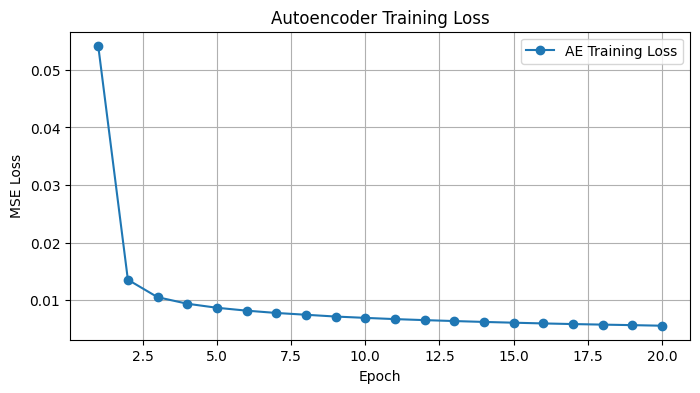

In [33]:
plt.figure(figsize=(8, 4))
plt.plot(
    range(1, EPOCHS + 1),
    ae_losses,
    marker="o",
    label="AE Training Loss"
)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.grid()
plt.show()


# 8.4 Autoencoder Reconstruction Results

Original images are compared with their reconstructed outputs.


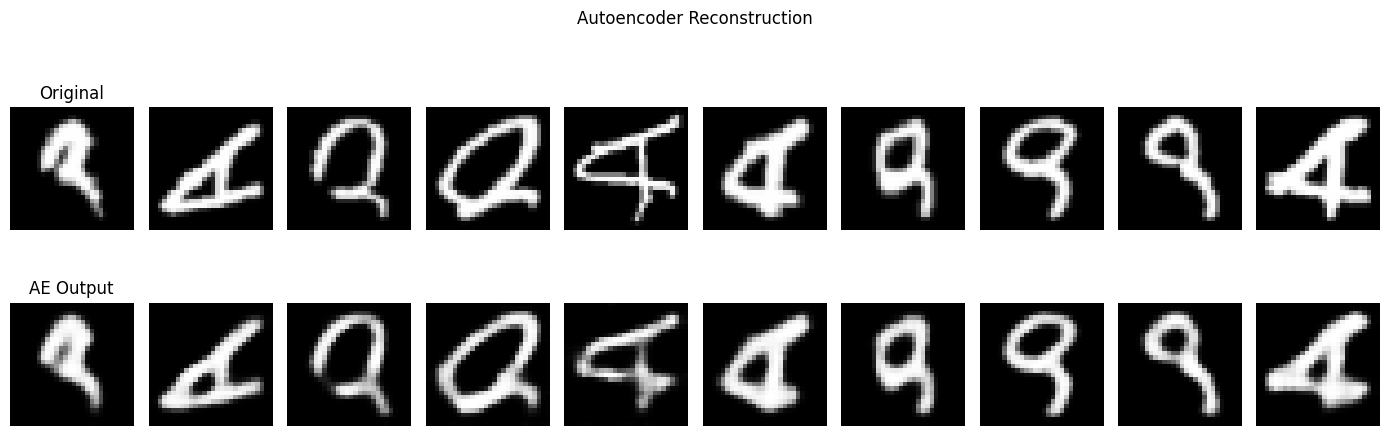

In [34]:
ae.eval()

with torch.no_grad():
    sample_images, sample_labels = next(iter(test_loader))
    sample_images = sample_images[:10].to(device)
    ae_reconstructed = ae(sample_images)

plt.figure(figsize=(14, 5))

for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(sample_images[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Original")

    plt.subplot(2, 10, i + 11)
    plt.imshow(ae_reconstructed[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("AE Output")

plt.suptitle("Autoencoder Reconstruction")
plt.tight_layout()
plt.show()


# 8.5 Autoencoder Test Reconstruction Error

The model is evaluated on the unseen test subset using average MSE.


In [35]:
ae.eval()
ae_test_loss = 0

with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)
        output = ae(x)
        ae_test_loss += criterion(output, x).item()

ae_test_loss /= len(test_loader)

print(f"Autoencoder Test MSE: {ae_test_loss:.6f}")


Autoencoder Test MSE: 0.006846


# 9. Task 3: Variational Autoencoder

The VAE uses the same general encoder-decoder idea, but its encoder learns a distribution through **μ** and **log variance**.

The reparameterization trick makes sampling differentiable during backpropagation.


In [36]:
class VAE(nn.Module):
    def __init__(self, latent_dim=32):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

        self.fc_mu = nn.Linear(64 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(64 * 7 * 7, latent_dim)

        self.decoder_input = nn.Linear(latent_dim, 64 * 7 * 7)

        self.decoder = nn.Sequential(
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(
                64, 32, 3, stride=2,
                padding=1, output_padding=1
            ),
            nn.ReLU(),
            nn.ConvTranspose2d(
                32, 1, 3, stride=2,
                padding=1, output_padding=1
            ),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        output = self.decode(z)
        return output, mu, logvar

vae = VAE(LATENT_DIM).to(device)

print(vae)


VAE(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_mu): Linear(in_features=3136, out_features=32, bias=True)
  (fc_logvar): Linear(in_features=3136, out_features=32, bias=True)
  (decoder_input): Linear(in_features=32, out_features=3136, bias=True)
  (decoder): Sequential(
    (0): Unflatten(dim=1, unflattened_size=(64, 7, 7))
    (1): ConvTranspose2d(64, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (2): ReLU()
    (3): ConvTranspose2d(32, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (4): Sigmoid()
  )
)


# 9.1 VAE Parameter Count


In [37]:
vae_params = sum(p.numel() for p in vae.parameters() if p.requires_grad)

print("Trainable VAE parameters:", f"{vae_params:,}")


Trainable VAE parameters: 341,825


# 9.2 VAE Loss Function

The VAE objective combines:

- Reconstruction MSE
- KL divergence

A small β value is used to keep reconstruction quality reasonable while still regularizing the latent distribution.


In [38]:
def vae_loss(output, x, mu, logvar, beta=BETA):
    reconstruction_loss = nn.functional.mse_loss(
        output, x, reduction="sum"
    )

    kl_loss = -0.5 * torch.sum(
        1 + logvar - mu.pow(2) - logvar.exp()
    )

    total_loss = reconstruction_loss + beta * kl_loss

    return total_loss, reconstruction_loss, kl_loss


# 9.3 VAE Training

The training loop records total loss, reconstruction loss, and KL divergence separately so that the learning behavior can be analyzed.


In [39]:
vae_optimizer = optim.Adam(vae.parameters(), lr=LEARNING_RATE)

vae_losses = []
vae_recon_losses = []
vae_kl_losses = []

start_time = time.time()

for epoch in range(EPOCHS):
    vae.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for x, _ in train_loader:
        x = x.to(device, non_blocking=True)

        vae_optimizer.zero_grad()

        output, mu, logvar = vae(x)

        loss, recon_loss, kl_loss = vae_loss(
            output, x, mu, logvar
        )

        loss.backward()
        vae_optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    avg_loss = total_loss / len(train_ds)
    avg_recon = total_recon / len(train_ds)
    avg_kl = total_kl / len(train_ds)

    vae_losses.append(avg_loss)
    vae_recon_losses.append(avg_recon)
    vae_kl_losses.append(avg_kl)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Total: {avg_loss:.6f} | "
        f"Recon: {avg_recon:.6f} | "
        f"KL: {avg_kl:.6f}"
    )

vae_time = time.time() - start_time
print(f"VAE training time: {vae_time:.2f} seconds")


Epoch [1/20] Total: 38.304076 | Recon: 38.094004 | KL: 420.143446
Epoch [2/20] Total: 10.251742 | Recon: 10.101480 | KL: 300.524312
Epoch [3/20] Total: 8.240565 | Recon: 8.116313 | KL: 248.505267
Epoch [4/20] Total: 7.490235 | Recon: 7.376008 | KL: 228.454190
Epoch [5/20] Total: 6.992245 | Recon: 6.883915 | KL: 216.660936
Epoch [6/20] Total: 6.601487 | Recon: 6.497083 | KL: 208.807860
Epoch [7/20] Total: 6.297984 | Recon: 6.197138 | KL: 201.692868
Epoch [8/20] Total: 5.995338 | Recon: 5.897585 | KL: 195.506922
Epoch [9/20] Total: 5.755784 | Recon: 5.660521 | KL: 190.526435
Epoch [10/20] Total: 5.530234 | Recon: 5.437074 | KL: 186.321341
Epoch [11/20] Total: 5.342725 | Recon: 5.251718 | KL: 182.012200
Epoch [12/20] Total: 5.195469 | Recon: 5.106382 | KL: 178.172882
Epoch [13/20] Total: 5.052617 | Recon: 4.965129 | KL: 174.974480
Epoch [14/20] Total: 4.931361 | Recon: 4.844789 | KL: 173.143859
Epoch [15/20] Total: 4.830720 | Recon: 4.745223 | KL: 170.993138
Epoch [16/20] Total: 4.751238 

# 9.4 VAE Training Curves

The total VAE loss and its two components are plotted separately.


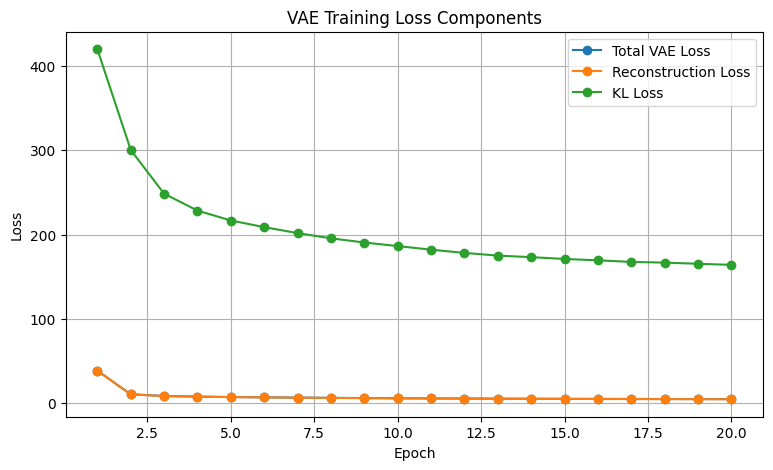

In [40]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, EPOCHS + 1), vae_losses, marker="o", label="Total VAE Loss")
plt.plot(range(1, EPOCHS + 1), vae_recon_losses, marker="o", label="Reconstruction Loss")
plt.plot(range(1, EPOCHS + 1), vae_kl_losses, marker="o", label="KL Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Loss Components")
plt.legend()
plt.grid()
plt.show()


# 9.5 VAE Reconstruction Results


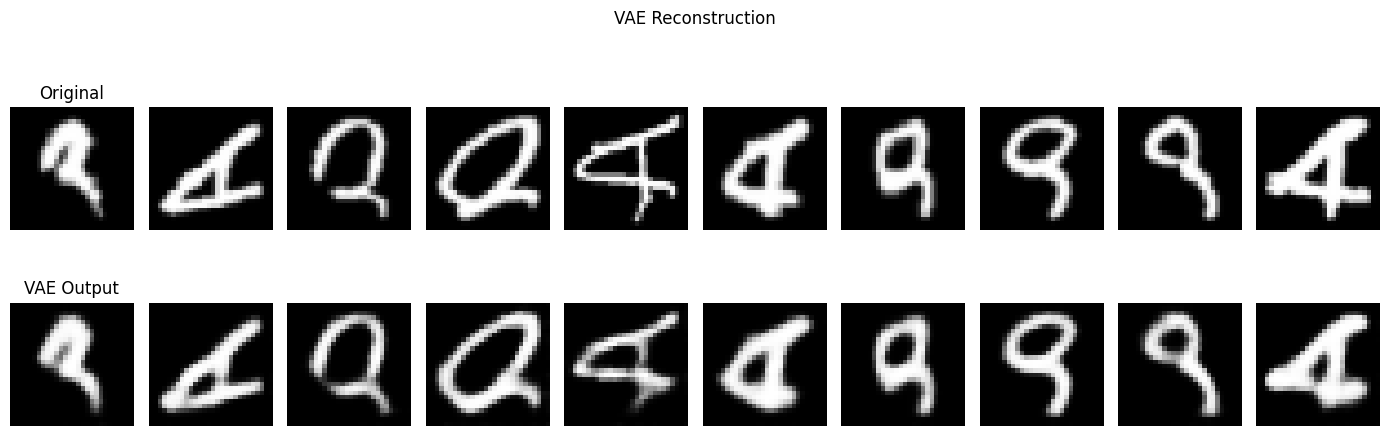

In [41]:
vae.eval()

with torch.no_grad():
    sample_images, sample_labels = next(iter(test_loader))
    sample_images = sample_images[:10].to(device)
    vae_reconstructed, _, _ = vae(sample_images)

plt.figure(figsize=(14, 5))

for i in range(10):
    plt.subplot(2, 10, i + 1)
    plt.imshow(sample_images[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Original")

    plt.subplot(2, 10, i + 11)
    plt.imshow(vae_reconstructed[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("VAE Output")

plt.suptitle("VAE Reconstruction")
plt.tight_layout()
plt.show()


# 9.6 VAE Test Reconstruction Error


In [42]:
vae_test_recon = 0
count = 0

with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)

        output, _, _ = vae(x)

        batch_mse = nn.functional.mse_loss(
            output, x, reduction="mean"
        )

        vae_test_recon += batch_mse.item()
        count += 1

vae_test_recon /= count

print("VAE Test Reconstruction MSE:", vae_test_recon)

VAE Test Reconstruction MSE: 0.006853019254049286


# 10. Task 4: Image Generation Using VAE

The VAE can generate new images because its latent space is regularized toward a standard normal distribution.

Random latent vectors are sampled from **N(0, I)** and passed through the decoder.


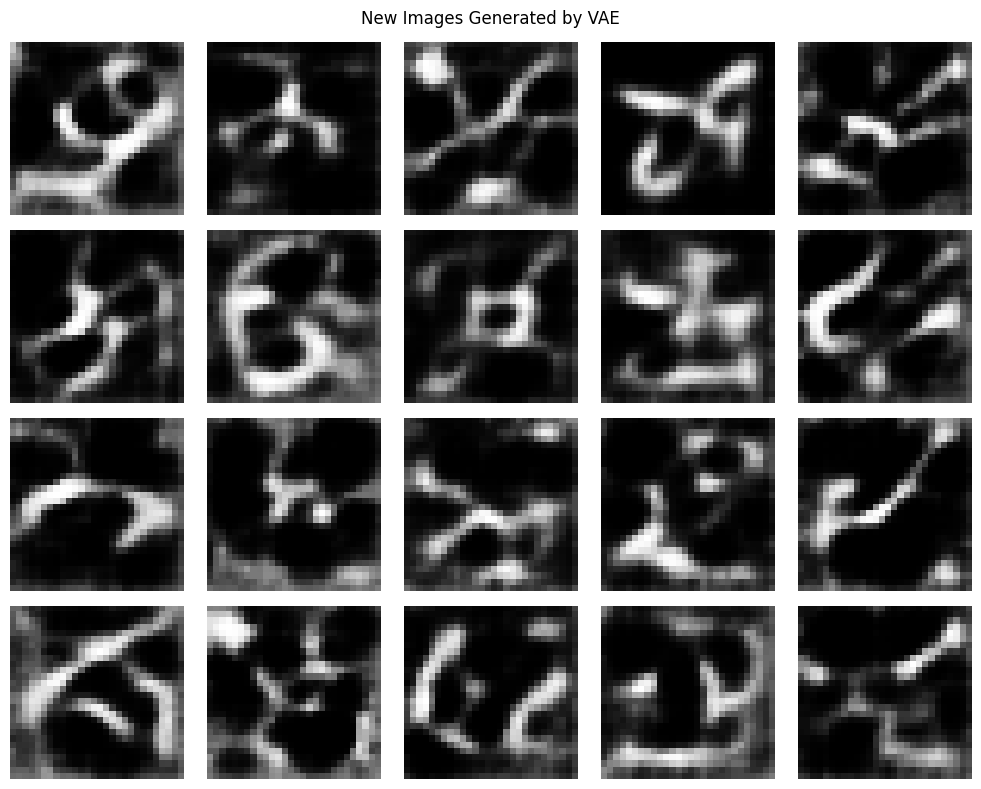

In [43]:
vae.eval()

with torch.no_grad():
    z = torch.randn(20, LATENT_DIM).to(device)
    generated = vae.decode(z)

plt.figure(figsize=(10, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(generated[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")

plt.suptitle("New Images Generated by VAE")
plt.tight_layout()
plt.show()


# 10.1 Generated Image Analysis

The generated images are not reconstructions of specific test images. They are samples produced by decoding random latent vectors.

The quality of generated letters depends on the learned latent distribution, model capacity, number of epochs, and the amount of training data.


# 11. Task 5: Latent Space Visualization

To provide additional analysis, the first two dimensions of the learned latent representation are visualized.

For the Autoencoder, the encoded latent vector is plotted.

For the VAE, the learned **μ** vector is plotted because it represents the center of the encoder's learned distribution.

This is a visualization only; the actual models use all 32 latent dimensions.


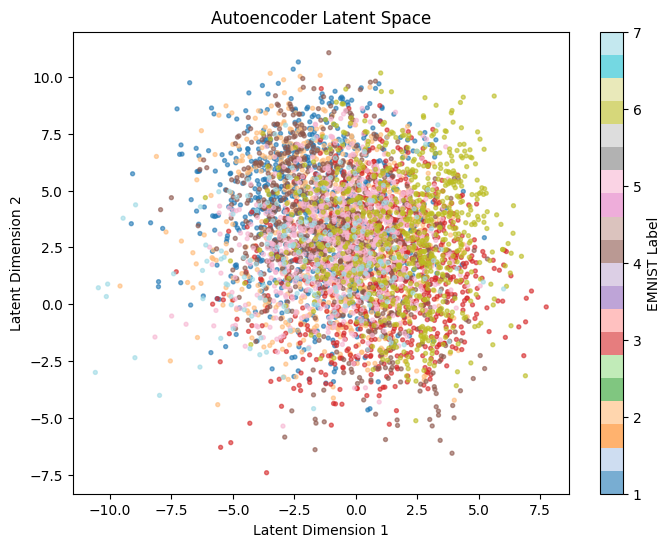

In [44]:
# Autoencoder latent-space visualization

ae.eval()
ae_latent_points = []
ae_latent_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        z = ae.encoder(x)

        ae_latent_points.append(z[:, :2].cpu())
        ae_latent_labels.append(y.cpu())

ae_latent_points = torch.cat(ae_latent_points).numpy()
ae_latent_labels = torch.cat(ae_latent_labels).numpy()

plt.figure(figsize=(8, 6))
plt.scatter(
    ae_latent_points[:, 0],
    ae_latent_points[:, 1],
    c=ae_latent_labels,
    s=8,
    alpha=0.6,
    cmap="tab20"
)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("Autoencoder Latent Space")
plt.colorbar(label="EMNIST Label")
plt.show()


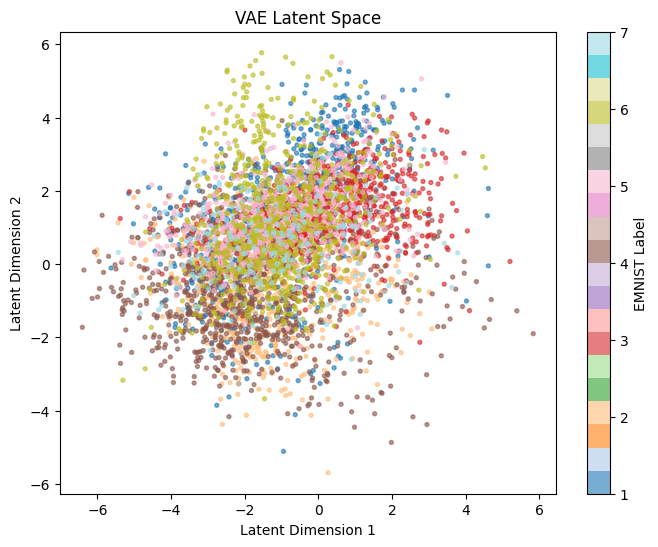

In [45]:
# VAE latent-space visualization

vae.eval()
vae_latent_points = []
vae_latent_labels = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        mu, logvar = vae.encode(x)

        vae_latent_points.append(mu[:, :2].cpu())
        vae_latent_labels.append(y.cpu())

vae_latent_points = torch.cat(vae_latent_points).numpy()
vae_latent_labels = torch.cat(vae_latent_labels).numpy()

plt.figure(figsize=(8, 6))
plt.scatter(
    vae_latent_points[:, 0],
    vae_latent_points[:, 1],
    c=vae_latent_labels,
    s=8,
    alpha=0.6,
    cmap="tab20"
)
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.title("VAE Latent Space")
plt.colorbar(label="EMNIST Label")
plt.show()


# 12. Task 6: Quantitative Performance Comparison

For this practical, **test reconstruction MSE** is the main quantitative metric.

Lower MSE indicates lower pixel-wise reconstruction error. However, numerical MSE alone is not sufficient for judging a generative model, so it is considered together with the reconstruction and generation images.


In [46]:
comparison = pd.DataFrame({
    "Model": ["Autoencoder", "Variational Autoencoder"],
    "Test Reconstruction MSE": [
        ae_test_loss,
        vae_test_recon
    ],
    "Trainable Parameters": [
        ae_params,
        vae_params
    ],
    "Training Time (seconds)": [
        ae_time,
        vae_time
    ]
})

comparison


,Model,Test Reconstruction MSE,Trainable Parameters,Training Time (seconds)
0,Autoencoder,0.006846,241441,77.786454
1,Variational Autoencoder,0.006853,341825,80.559099


## 12.3 Result Comparison

The actual numerical values below are produced after running the notebook. The final comparison should consider both numerical reconstruction error and visual quality.

| **Evaluation Aspect** | **Autoencoder** | **VAE** |
|---|---|---|
| Reconstruction | Directly optimized for reconstruction | Reconstruction is combined with latent regularization |
| Test metric | Test Reconstruction MSE | Test Reconstruction MSE |
| Image generation | Limited from arbitrary random latent vectors | Supported using random latent vectors |
| Latent space | Deterministic | Probabilistic and regularized |
| Generated images | Not the primary objective | Primary generative capability |
| Typical visual behavior | Can preserve sharper strokes | Can produce smoother outputs |
| Main role in this experiment | Reconstruction model | Reconstruction + generation model |


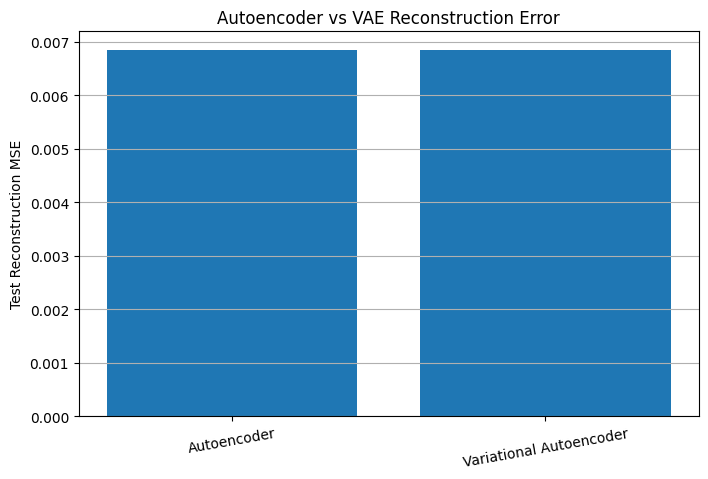

In [47]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["Test Reconstruction MSE"]
)

plt.ylabel("Test Reconstruction MSE")
plt.title("Autoencoder vs VAE Reconstruction Error")
plt.xticks(rotation=10)
plt.grid(axis="y")
plt.show()


# 12.1 Side-by-Side Reconstruction Comparison


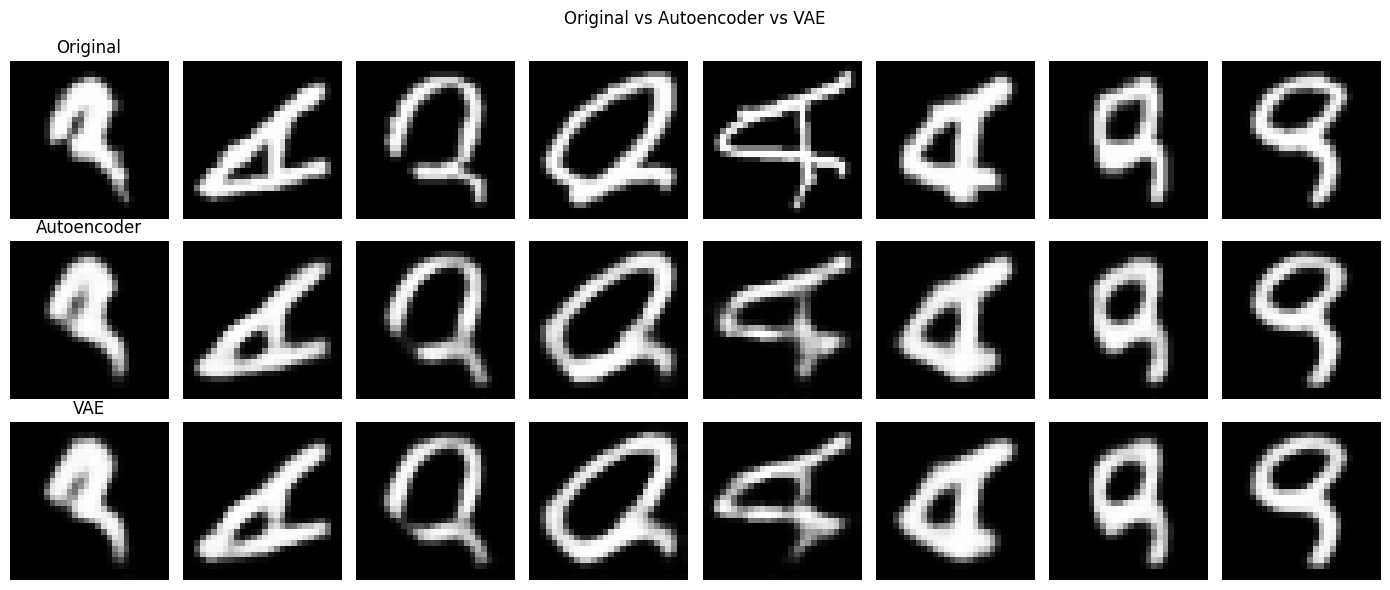

In [48]:
ae.eval()
vae.eval()

with torch.no_grad():
    comparison_images, _ = next(iter(test_loader))
    comparison_images = comparison_images[:8].to(device)

    ae_out = ae(comparison_images)
    vae_out, _, _ = vae(comparison_images)

plt.figure(figsize=(14, 6))

for i in range(8):
    plt.subplot(3, 8, i + 1)
    plt.imshow(comparison_images[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Original")

    plt.subplot(3, 8, i + 9)
    plt.imshow(ae_out[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("Autoencoder")

    plt.subplot(3, 8, i + 17)
    plt.imshow(vae_out[i].cpu().squeeze(), cmap="gray")
    plt.axis("off")
    if i == 0:
        plt.title("VAE")

plt.suptitle("Original vs Autoencoder vs VAE")
plt.tight_layout()
plt.show()


# 13. Model Analysis

## Autoencoder

- Learns a compact representation optimized primarily for reconstruction.
- Does not explicitly force the latent space to follow a known probability distribution.
- Reconstruction quality can be strong because the model directly minimizes reconstruction error.
- Random sampling from its latent space is not guaranteed to produce meaningful images.

## Variational Autoencoder

- Learns a probabilistic latent representation using μ and log variance.
- KL divergence regularizes the latent space.
- Random latent vectors can be sampled and decoded to create new images.
- Reconstructions can be smoother because the model balances reconstruction and latent-space regularization.

## Overall interpretation

The Autoencoder and VAE solve related but slightly different objectives. The Autoencoder emphasizes faithful reconstruction, whereas the VAE adds a structured latent space that makes generation possible.


# 14. Result Discussion

The final result should be discussed using both quantitative and qualitative evidence.

### Reconstruction

The model with the lower test MSE has lower pixel-wise reconstruction error on the selected test subset. The displayed reconstruction grid should also be inspected for preservation of letter shape and stroke structure.

### Generation

The VAE demonstrates the generative capability required by the practical by producing images from random latent vectors.

### Latent representation

The latent-space plots provide additional evidence of what the models have learned. The VAE is expected to show a more regularized representation because of the KL-divergence term.

> The exact numerical values and visual appearance depend on the Colab hardware, random initialization, training duration, and the selected subset.


# 15. Strengths and Limitations

## Strengths

1. Uses a Convolutional Autoencoder suitable for image data.
2. Implements a VAE with the reparameterization trick.
3. Performs both reconstruction and generation.
4. Provides quantitative reconstruction comparison.
5. Includes visual comparison of original and reconstructed images.
6. Includes latent-space analysis for deeper understanding.

## Limitations

1. EMNIST images are small 28×28 grayscale images.
2. Only a subset of the available training data is used.
3. The VAE-generated letters may not always be clearly recognizable after a short practical training run.
4. MSE does not fully represent perceptual image quality.
5. The experiment does not perform extensive hyperparameter tuning.


# 16. Conclusion

This practical implemented both a **Convolutional Autoencoder** and a **Variational Autoencoder** using the EMNIST Letters dataset.

The Autoencoder learned a compact representation for reconstructing handwritten letters. The VAE learned a probabilistic latent representation using reconstruction loss and KL divergence, and it was able to generate new images from randomly sampled latent vectors.

The comparison demonstrates an important distinction: an Autoencoder is primarily focused on reconstruction, while a VAE provides a structured latent space that supports both reconstruction and image generation.

Therefore, the practical successfully demonstrates the use of Autoencoders and Variational Autoencoders for image reconstruction and generation.


# 17. Declaration

I, **Shreya Dattaram Bhosale**, confirm that the work submitted in this practical has been completed for the Generative AI Lab and follows the required academic guidelines.

The notebook contains the implementation, experimental results, comparison, observations, and conclusion for Practical No. 03.
